## create environment

        conda create -n imgcluster python=3.11 -c conda-forge -y
        conda activate imgcluster
        pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cpu
        pip install open_clip_torch transformers accelerate umap-learn hdbscan plotly ipywidgets pillow tqdm ipykernel pandas nbformat matplotlib seaborn


In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image


In [2]:
# 2. gather all image paths
# root = Path(os.path.abspath(""))
# paths = sorted(root.rglob("*.png")) + sorted(root.rglob("*.jpg"))
# print(f"Found {len(paths)} images")

In [3]:
# 2. gather all image paths
root = Path(os.path.abspath(""))
csv_path = os.path.join(root, "parsed_results.csv")
csv = pd.read_csv(csv_path)
csv["render_image_path"] = csv["render_image_path"].apply(lambda x: Path(os.path.join(root, x)))
paths = [Path(os.path.join(root, p)) for p in csv["render_image_path"].tolist()]
print(f"Found {len(paths)} images")
# check if all paths exist
for path in paths:
    if not path.exists():
        print(f"Path does not exist: {path}")

Found 138 images


In [4]:
# --- 3 ▒ merge tables ---------------------------------------------------------
df = pd.DataFrame({"render_image_path": paths, "idx": np.arange(len(paths))})
# round numeric scores to nearest int (1-5) for colouring
# score_cols = [
#     "design_concept_strength",
#     "material_strategy_coherence",
#     "design_task_quality",
#     "facade_potential",
#     "average_score",
# ]
df = df.merge(csv, on="render_image_path", how="left")  # keeps row order
# # for c in score_cols:
# #     df[c + "_round"] = df[c].round().astype("Int64")  # keep NaN as <NA>
# # ── 1 ▒  drop rows with *any* NaN score ---------------------------------------
# # before = len(df)
# # df = df.dropna(subset=score_cols)
# # after = len(df)
# # print(f"Dropped {before-after} rows with missing scores → {after} left")
df.head()

,render_image_path,idx,project_folder,run_number,material,reference_image_path,tectonic_framework,facade_potential,material_specificity,average_score,improvement_target,improvement_proposal,total_iterations
0,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,0,R01_clay,0,clay,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,2,4,2,2.67,design_concept,Refocus the design task around a specific clay...,7
1,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,1,R01_clay,1,clay,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,2,4,2,2.67,design_concept,Refocus the design task around a specific clay...,7
2,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,2,R01_clay,2,clay,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,2,4,2,2.67,design_concept,Refocus the design task around a specific clay...,7
3,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,3,R01_clay,3,clay,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,2,4,2,2.67,design_concept,Refocus the design task around a specific clay...,7
4,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,4,R01_clay,4,clay,c:\Users\marcr\OneDrive\Documentos\00_MarcRibe...,2,4,2,2.67,design_concept,Refocus the design task around a specific clay...,7


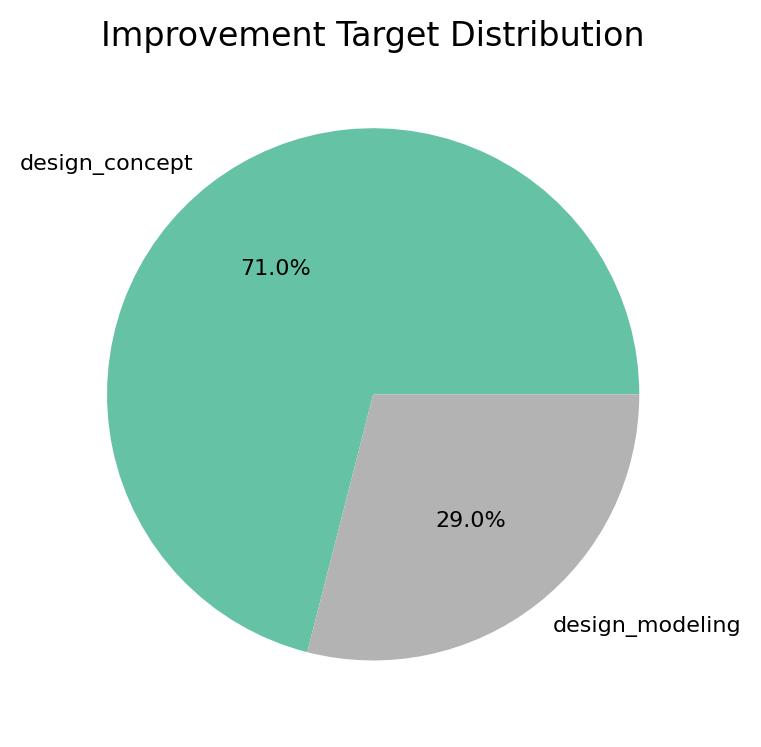

In [17]:
# Filter for the three categories
categories = ["design_concept", "design_modeling"]
counts = df["improvement_target"].value_counts()
# Safely filter for categories that exist, using reindex to handle missing ones
filtered_counts = counts.reindex(categories, fill_value=0)

# Plot
plt.figure(figsize=(4, 4), dpi=200)
filtered_counts.plot(
    kind="pie", 
    # color=["#4e79a7", "#f28e2b", "#76b7b2"],
    colormap="Set2",
    autopct='%1.1f%%',  # Add percentages
    ylabel='',  # Remove the ylabel (count label)
    legend=False,
    textprops={'fontsize': 8}  # Make label text smaller
)
plt.title("Improvement Target Distribution", fontsize=12)  # Smaller title font
plt.tight_layout(h_pad=2, w_pad=2)

plt.savefig(
    "_clustering_plots/improvement_target_distribution.pdf",
    dpi=200,
    bbox_inches="tight",
    format='pdf'
)
plt.savefig(
    "_clustering_plots/improvement_target_distribution.jpg",
    dpi=200,
    bbox_inches="tight",
    format='jpg'
)

plt.show()

C:\Users\marcr\AppData\Local\Temp\ipykernel_46752\1382294278.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(boxplot_data, labels=metric_labels, patch_artist=True,


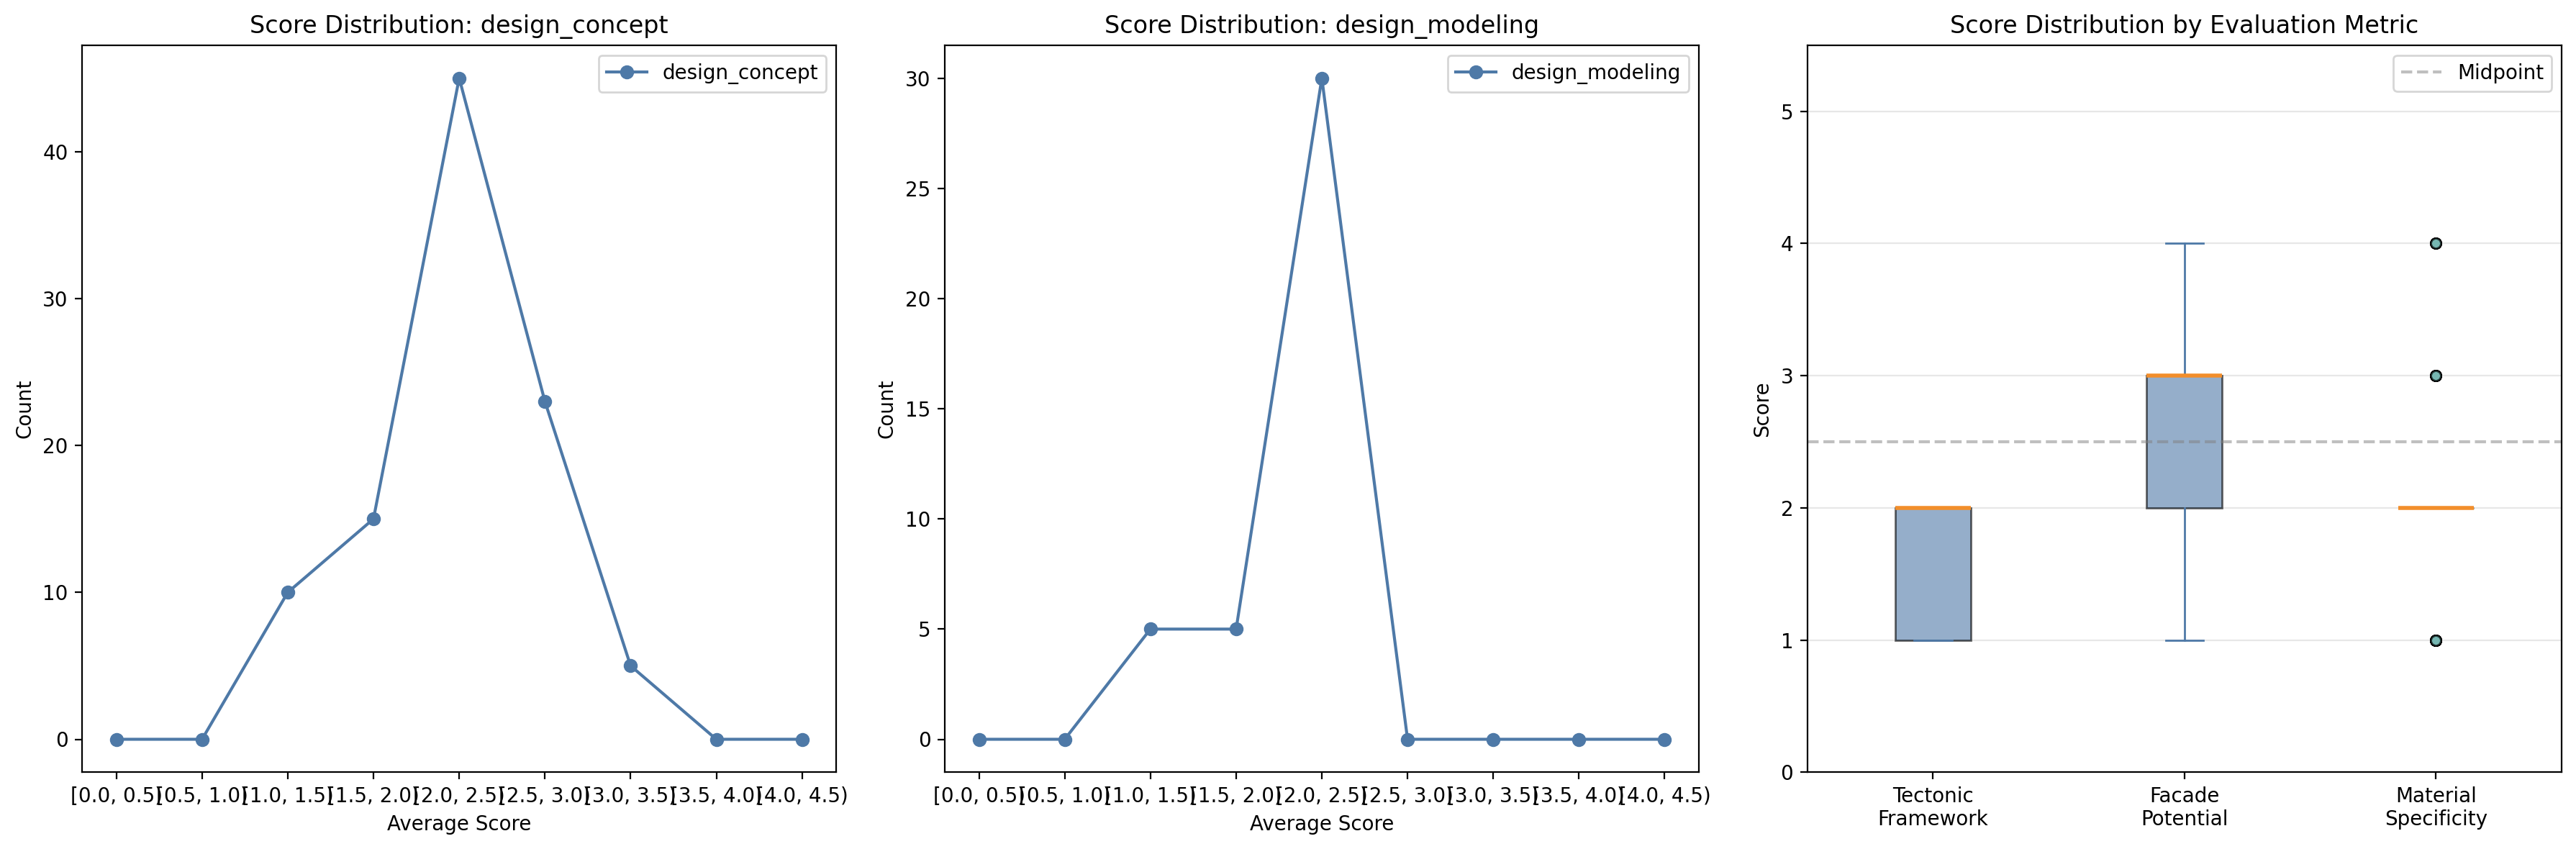

In [22]:
# Average score distribution by improvement target
df['average_score_range'] = pd.cut(df['average_score'], bins=[i/2 for i in range(10)], right=False)

# Create a single figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=200)

# First two plots: Score distribution by improvement target
for i, cat in enumerate(categories):
    subcat = df.loc[df['improvement_target'] == cat]
    
    if len(subcat) > 0:
        score_group = subcat.groupby('average_score_range', observed=False).size()
        
        # Plot on the specific subplot
        score_group.plot(kind='line', marker='o', color='#4e79a7', ax=axes[i], label=cat)
        
        axes[i].set_xlabel('Average Score')
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'Score Distribution: {cat}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center', va='center', transform=axes[i].transAxes, fontsize=14)
        axes[i].set_title(f'Score Distribution: {cat}')

# Third plot: Boxplot of scores by evaluation metric
evaluation_metrics = ['tectonic_framework', 'facade_potential', 'material_specificity']
metric_labels = ['Tectonic\nFramework', 'Facade\nPotential', 'Material\nSpecificity']

# Prepare data for boxplot
boxplot_data = [df[metric].dropna() for metric in evaluation_metrics]

# Create boxplot
ax3 = axes[2]
bp = ax3.boxplot(boxplot_data, labels=metric_labels, patch_artist=True,
                  boxprops=dict(facecolor='#4e79a7', alpha=0.6),
                  medianprops=dict(color='#f28e2b', linewidth=2),
                  whiskerprops=dict(color='#4e79a7'),
                  capprops=dict(color='#4e79a7'),
                  flierprops=dict(marker='o', markerfacecolor='#76b7b2', markersize=5, alpha=0.5))

ax3.set_ylabel('Score')
ax3.set_title('Score Distribution by Evaluation Metric')
ax3.set_ylim([0, 5.5])
ax3.axhline(y=2.5, color='gray', linestyle='--', alpha=0.5, label='Midpoint')
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

plt.tight_layout()

plt.savefig(
    "_clustering_plots/score_distribution_by_target.pdf",
    dpi=200,
    bbox_inches="tight",
    format='pdf'
)
plt.savefig(
    "_clustering_plots/score_distribution_by_target.jpg",
    dpi=200,
    bbox_inches="tight",
    format='jpg'
)

plt.show()

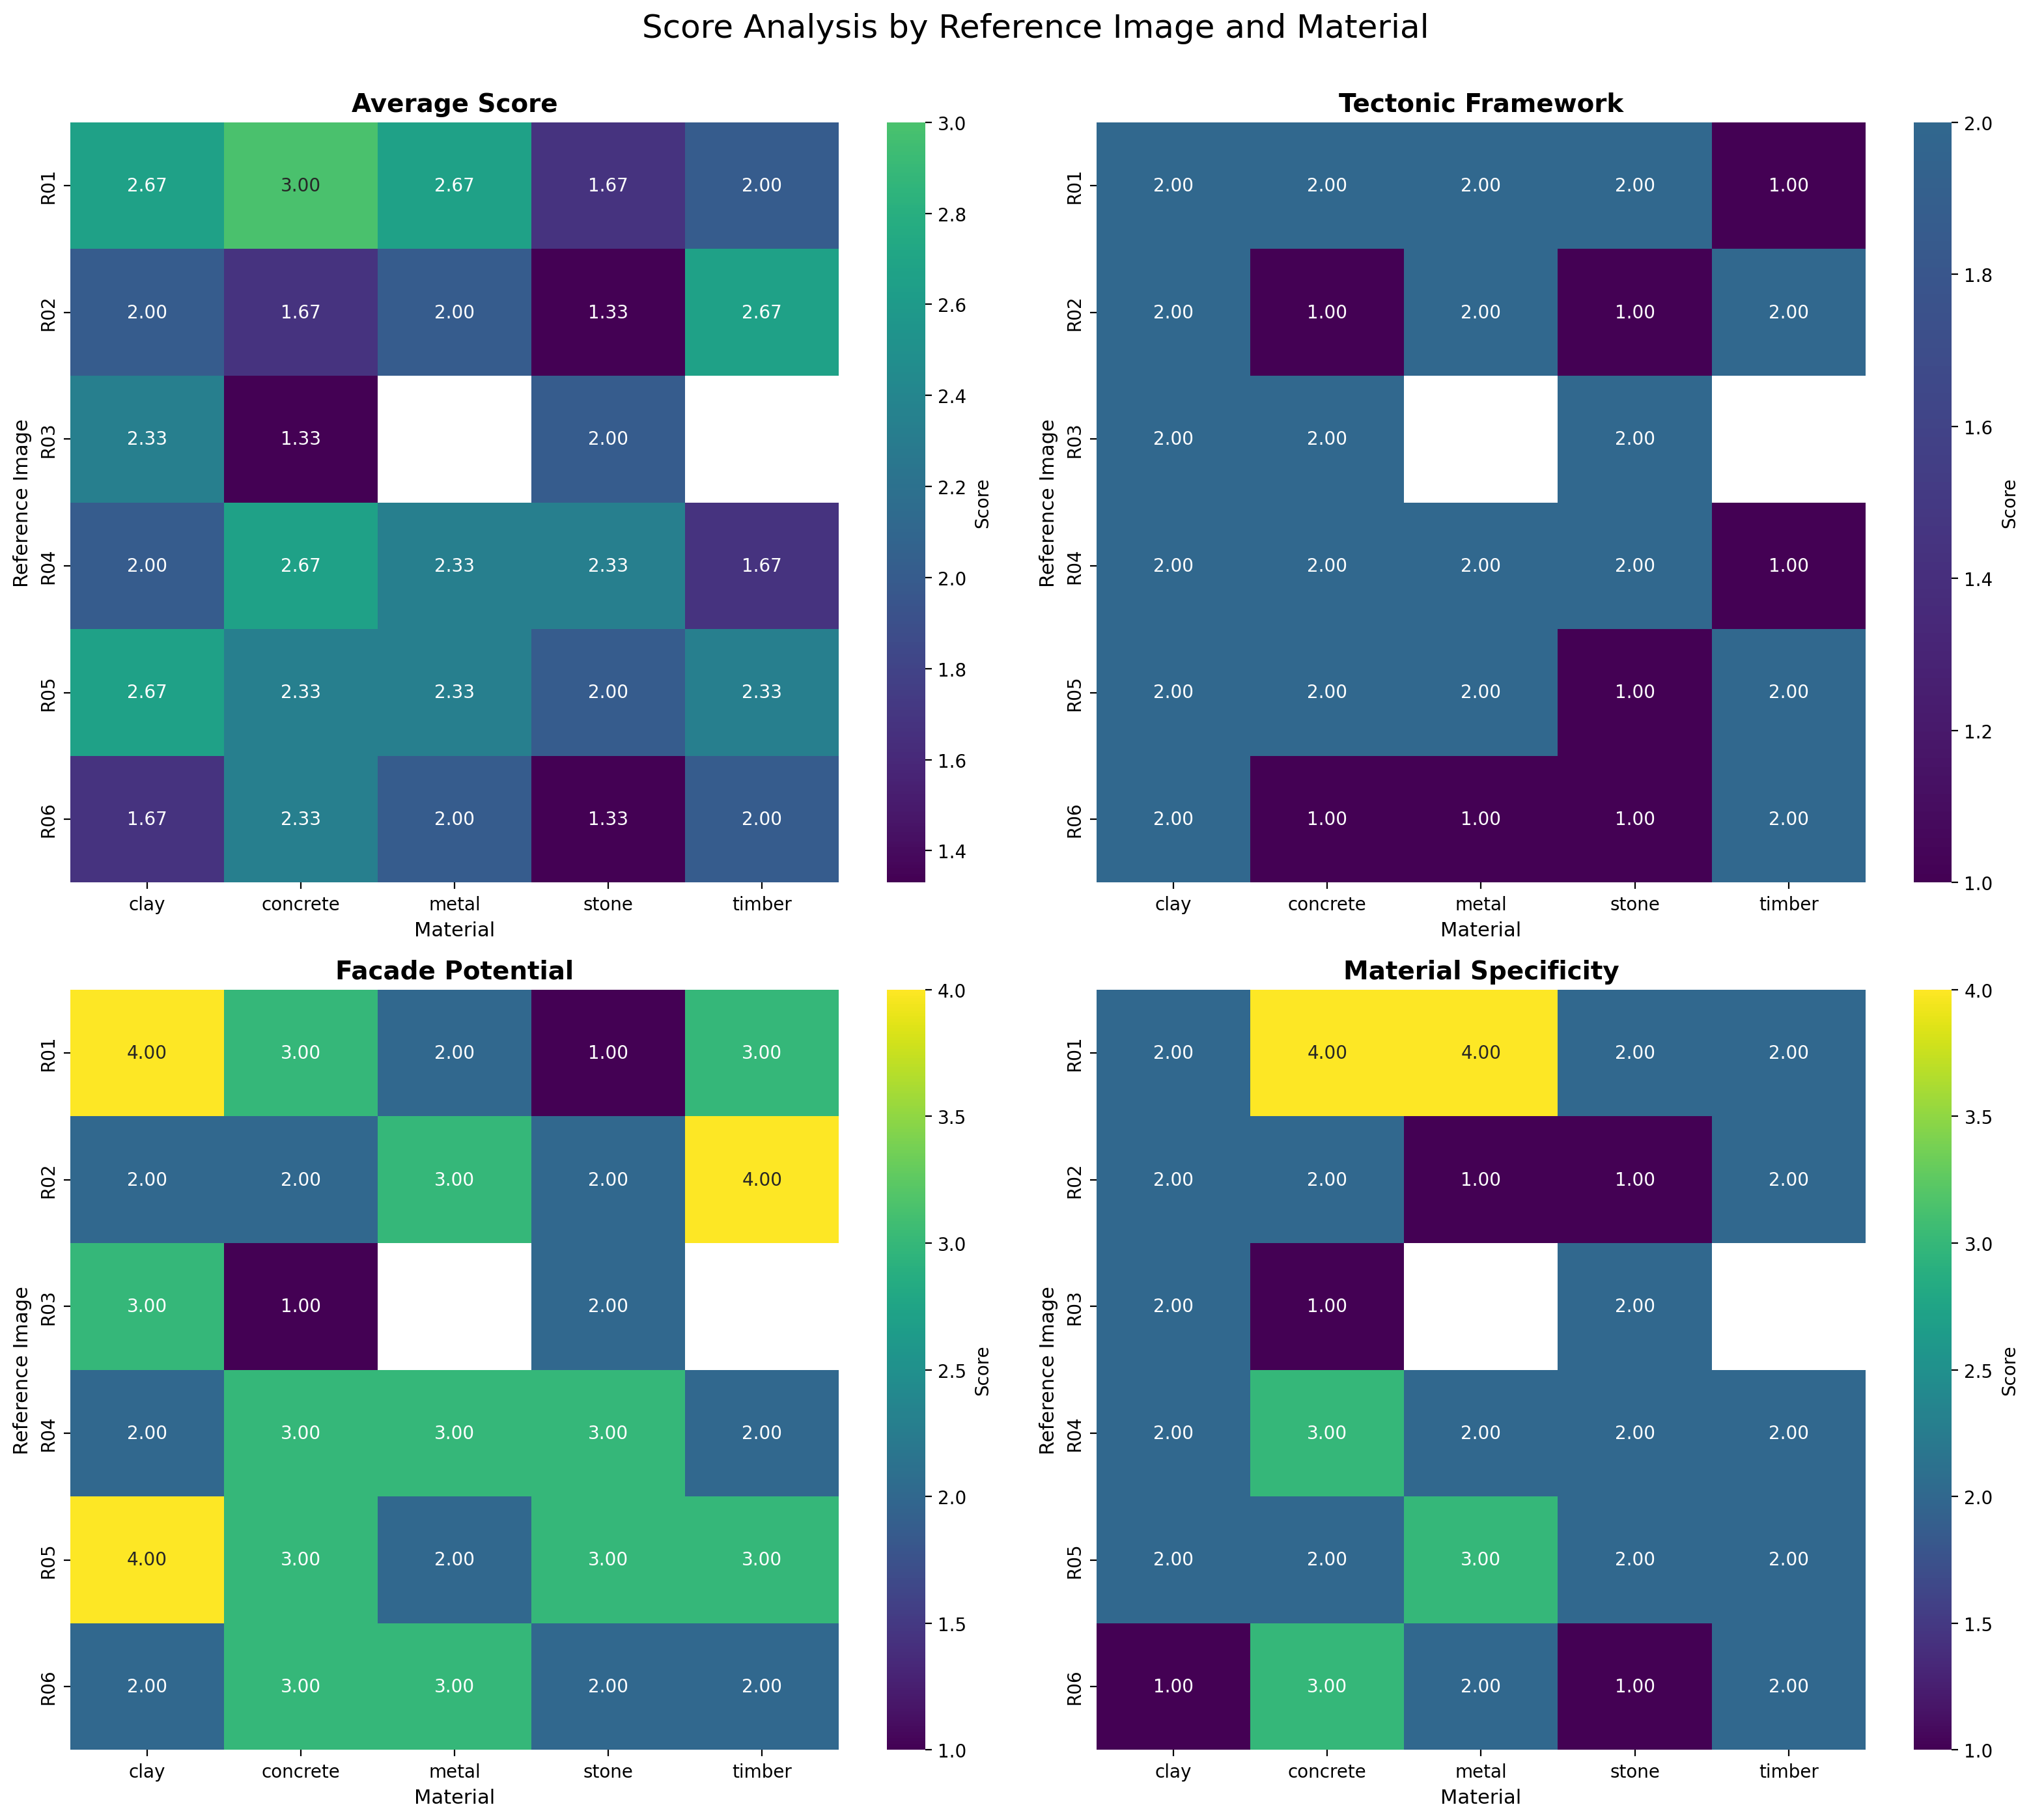

In [24]:
# Extract reference image from project_folder (e.g., "R01_clay" -> "R01")
df['reference_id'] = df['project_folder'].str.split('_').str[0]

# Create a 2x2 figure with heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 14), dpi=200)

# Define the metrics and their labels
metrics = ['average_score', 'tectonic_framework', 'facade_potential', 'material_specificity']
titles = ['Average Score', 'Tectonic Framework', 'Facade Potential', 'Material Specificity']

# Flatten axes for easier iteration
axes_flat = axes.flatten()

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes_flat[idx]
    
    # Create pivot table with reference_id as rows and material as columns
    pivot_data = df.pivot_table(
        values=metric, 
        index='reference_id', 
        columns='material', 
        aggfunc='mean'
    )
    
    # Create the heatmap
    sns.heatmap(
        pivot_data, 
        annot=True, 
        fmt='.2f', 
        cmap='viridis', 
        center=2.5,  # Center the colormap around the middle score
        cbar_kws={'label': 'Score'},
        ax=ax,
        cbar=True
    )

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Material', fontsize=11)
    ax.set_ylabel('Reference Image', fontsize=11)

plt.suptitle('Score Analysis by Reference Image and Material', fontsize=18, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

plt.savefig(
    "_clustering_plots/score_heatmap_by_reference.pdf",
    dpi=200,
    bbox_inches="tight",
    format='pdf'
)
plt.savefig(
    "_clustering_plots/score_heatmap_by_reference.jpg",
    dpi=200,
    bbox_inches="tight",
    format='jpg'
)

plt.show()

In [25]:
# Define materials and reference images
materials = ["clay", "concrete", "metal", "stone", "timber"]
reference_images = ["R01", "R02", "R03", "R04", "R05", "R06"]

In [26]:
# Find the highest scoring image for each reference image - material combination
print("Finding highest scoring images for each reference image - material combination...")

# Create a list to store the results
highest_scoring_images = []

for ref in reference_images:
    for mat in materials:
        # Filter for this specific combination
        subset = df[(df['reference_id'] == ref) & (df['material'] == mat)]
        
        if len(subset) > 0:
            # Find the row with highest average score
            max_score_idx = subset['average_score'].idxmax()
            max_score_row = subset.loc[max_score_idx]
            
            highest_scoring_images.append({
                'reference_id': ref,
                'material': mat,
                'average_score': max_score_row['average_score'],
                'render_image_path': max_score_row['render_image_path']
            })
            print(f"{ref}-{mat}: Score {max_score_row['average_score']:.2f}")
        else:
            print(f"No data for {ref}-{mat}")

print(f"\nFound {len(highest_scoring_images)} combinations with data")

Finding highest scoring images for each reference image - material combination...
R01-clay: Score 2.67
R01-concrete: Score 3.00
R01-metal: Score 2.67
R01-stone: Score 1.67
R01-timber: Score 2.00
R02-clay: Score 2.00
R02-concrete: Score 1.67
R02-metal: Score 2.00
R02-stone: Score 1.33
R02-timber: Score 2.67
R03-clay: Score 2.33
R03-concrete: Score 1.33
No data for R03-metal
R03-stone: Score 2.00
No data for R03-timber
R04-clay: Score 2.00
R04-concrete: Score 2.67
R04-metal: Score 2.33
R04-stone: Score 2.33
R04-timber: Score 1.67
R05-clay: Score 2.67
R05-concrete: Score 2.33
R05-metal: Score 2.33
R05-stone: Score 2.00
R05-timber: Score 2.33
R06-clay: Score 1.67
R06-concrete: Score 2.33
R06-metal: Score 2.00
R06-stone: Score 1.33
R06-timber: Score 2.00

Found 28 combinations with data


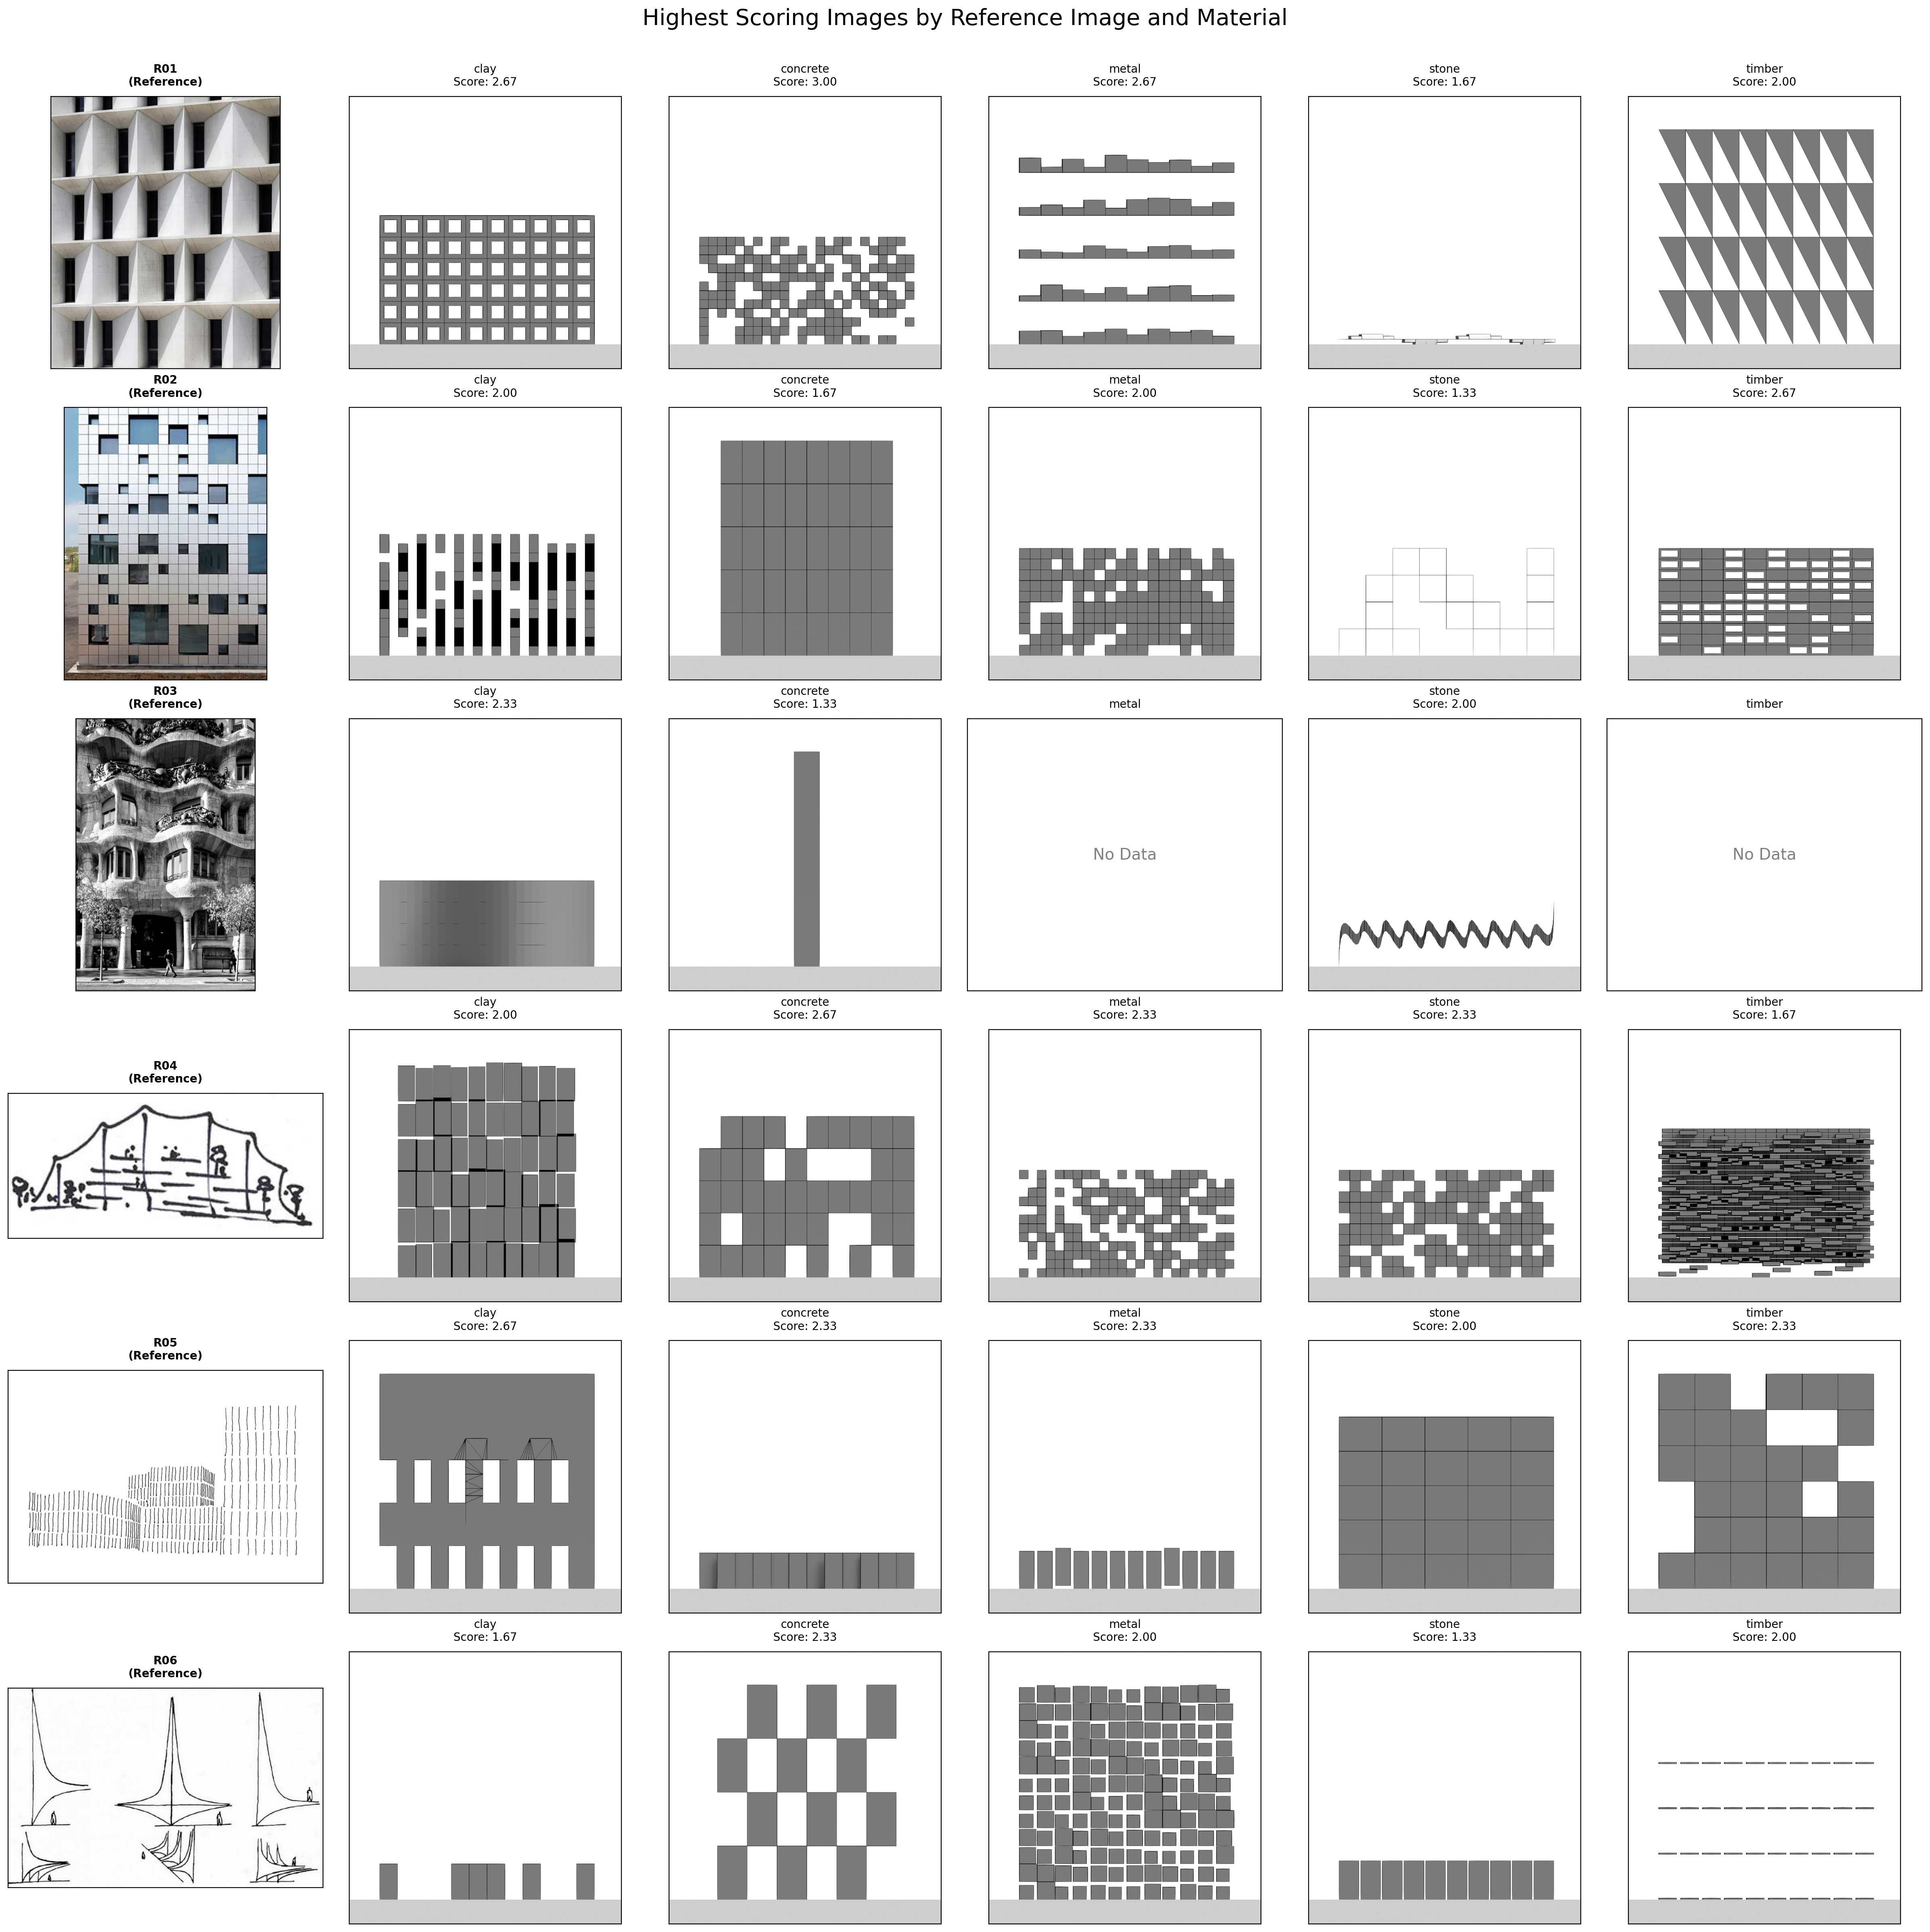


Displayed 28 images out of 30 possible combinations


In [27]:
# Create a grid visualization: reference images (rows) x [reference + materials] (columns)
fig, axes = plt.subplots(6, 6, figsize=(24, 24), dpi=200, squeeze=True)

# Create a mapping for easy access to rendered images
image_dict = {}
for item in highest_scoring_images:
    key = (item['reference_id'], item['material'])
    image_dict[key] = item

# Get reference image paths from the dataframe
reference_image_dict = {}
for ref in reference_images:
    subset = df[df['reference_id'] == ref]
    if len(subset) > 0:
        ref_path = subset.iloc[0]['reference_image_path']
        reference_image_dict[ref] = ref_path

# Plot images in grid: reference images as rows, reference + materials as columns
for i, ref in enumerate(reference_images):
    for j in range(6):
        ax = axes[i, j]
        
        if j == 0:
            # First column: show reference image
            if ref in reference_image_dict:
                try:
                    ref_img_path = reference_image_dict[ref]
                    img = Image.open(ref_img_path).convert('RGB')
                    ax.imshow(img)
                    ax.set_title(f'{ref}\n(Reference)', fontsize=10, pad=10, fontweight='bold')
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error loading\nreference', ha='center', va='center', transform=ax.transAxes, fontsize=8)
                    ax.set_title(f'{ref}\n(Reference)', fontsize=10, pad=10, fontweight='bold')
            else:
                ax.text(0.5, 0.5, 'No Ref', ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray')
                ax.set_title(f'{ref}\n(Reference)', fontsize=10, pad=10, fontweight='bold')
        else:
            # Remaining columns: show materials (j-1 to account for reference column)
            mat = materials[j - 1]
            key = (ref, mat)
            
            if key in image_dict:
                # Load and display rendered image
                img_path = image_dict[key]['render_image_path']
                score = image_dict[key]['average_score']
                
                try:
                    # Load image
                    img = Image.open(img_path).convert('RGB')
                    ax.imshow(img)
                    ax.set_title(f'{mat}\nScore: {score:.2f}', fontsize=10, pad=10)
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error loading\n{str(e)}', ha='center', va='center', transform=ax.transAxes, fontsize=8)
                    ax.set_title(f'{mat}\nScore: {score:.2f}', fontsize=10, pad=10)
            else:
                # No data for this combination
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=14, color='gray')
                ax.set_title(f'{mat}', fontsize=10, pad=10)
        
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Highest Scoring Images by Reference Image and Material', fontsize=20, y=0.995)
plt.tight_layout(rect=[0.00, 0.00, 1.00, 0.99], h_pad=0.5, w_pad=0.5)

plt.savefig(
    "_clustering_plots/highest_score_by_reference_material.pdf",
    dpi=200,
    bbox_inches="tight",
    format='pdf'
)
plt.savefig(
    "_clustering_plots/highest_score_by_reference_material.jpg",
    dpi=200,
    bbox_inches="tight",
    format='jpg'
)

plt.show()

print(f"\nDisplayed {len(highest_scoring_images)} images out of {len(reference_images) * len(materials)} possible combinations")